In [1]:
from pathlib import Path
from dataclasses import dataclass
from scipy.stats import chi2
from datetime import datetime, timedelta
from typing import *

import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np


ROOT_DIR = Path(os.getcwd()).parent

<h4>Rewrite polars code to Lazy api</h4>

In [2]:
@dataclass
class PumpEvent:
    ticker: str
    pump_time: str

    def __post_init__(self):
        self.pump_time = datetime.strptime(self.pump_time, "%Y-%m-%d %H:%M:%S")

pump = PumpEvent(ticker="EZBTC", pump_time="2021-10-31 16:59:59")

In [3]:
def create_date_range(start: datetime, end: datetime) -> List[str]:
    """Creates a range of months and years between two dates"""
    start_year = start.year
    start_month = start.month
    end_year = end.year
    end_month = end.month

    date_range = []

    for year in range(start_year, end_year + 1):
        start_month_range = start_month if year == start_year else 1
        end_month_range = end_month if year == end_year else 12

        for month in range(start_month_range, end_month_range + 1):
            date_range.append(datetime(year=year, month=month, day=1))

    return date_range

In [4]:
def load_lazy_data(pump_event: PumpEvent, lookback_delta: timedelta) -> pl.LazyFrame:
    rb = pump_event.pump_time
    lb = rb - lookback_delta

    ts_range = create_date_range(start=lb, end=rb)

    TICKER_DIR = os.path.join(ROOT_DIR, "data/trades", pump_event.ticker)

    dfs = []

    for date in ts_range:
        month, year = str(date.month).zfill(2), date.year
        slug = f"{pump_event.ticker}-{year}-{str(month).zfill(2)}.parquet"
        df_tmp = pl.scan_parquet(os.path.join(TICKER_DIR, slug))

        dfs.append(df_tmp)

    return pl.concat(dfs, how="vertical")

In [5]:
df: pl.LazyFrame = load_lazy_data(pump_event=pump, lookback_delta=timedelta(days=30))

window = "7d"

In [6]:
df_group = (
    df
    .with_columns(
        ((1 - 2 * pl.col("isBuyerMaker").cast(pl.Int8)) * pl.col("qty")).alias("qty_sign")
    )
    .group_by("time", maintain_order=True).agg(
    # Price aggregation
        price_first=pl.col("price").first(),
        price_last=pl.col("price").last(),
        price_min=pl.col("price").min(),
        price_max=pl.col("price").max(),
        qty_abs=pl.col("qty").sum(),
        qty_sign=pl.col("qty_sign").sum(),
    )
    .with_columns(
        time=pl.col("time").set_sorted()
    )
    .with_columns(
        date=pl.col("time").dt.truncate("1d")
    )
)

In [7]:
df_quantiles = (
    df_group
    .group_by_dynamic(
        index_column="time", every="1d"
    )
    .agg(
        qty_quantile=pl.col("qty_abs").quantile(.999)
    )
)

In [8]:
df_group = (
    df_group.join(df_quantiles, left_on="date", right_on="time", how="left")
    .with_columns(
        is_whale = (
            pl.col("qty_abs") >= pl.col("qty_quantile")
        ).cast(pl.Int8),
        is_buy = (
            pl.col("qty_sign") > 0
        ).cast(pl.Int8)
    )
    .with_columns(
        # Whale volumes
        rolling_qty_abs_whale_vol = (pl.col("qty_abs") * pl.col("is_whale")).rolling_sum(by="time", window_size=window),
        rolling_qty_sign_whale_vol = (pl.col("qty_sign") * pl.col("is_whale")).rolling_sum(by="time", window_size=window),
        # Regular volumes
        rolling_qty_abs_reg_vol = (pl.col("qty_abs") * ~pl.col("is_whale")).rolling_sum(by="time", window_size=window),
        rolling_qty_sign_reg_vol = (pl.col("qty_sign") * pl.col("is_whale")).rolling_sum(by="time", window_size=window),
    )
    .with_columns(
        whale_imbalance_ratio = pl.col("rolling_qty_sign_whale_vol") / pl.col("rolling_qty_abs_whale_vol"),
        regular_imbalance_ratio = pl.col("rolling_qty_sign_reg_vol") / pl.col("rolling_qty_abs_reg_vol")
    )
)

In [9]:
df_group = df_group.collect()
df_group.head()

time,price_first,price_last,price_min,price_max,qty_abs,qty_sign,date,qty_quantile,is_whale,is_buy,rolling_qty_abs_whale_vol,rolling_qty_sign_whale_vol,rolling_qty_abs_reg_vol,rolling_qty_sign_reg_vol,whale_imbalance_ratio,regular_imbalance_ratio
datetime[ns],f64,f64,f64,f64,f64,f64,datetime[ns],f64,i8,i8,f64,f64,f64,f64,f64,f64
2021-10-01 00:07:15.814,0.000106,0.000106,0.000106,0.000106,3.5,-3.5,2021-10-01 00:00:00,7500.8,0,0,0.0,0.0,-3.5,0.0,NaN,-0.0
2021-10-01 00:08:41.577,0.000107,0.000107,0.000107,0.000107,1.3,1.3,2021-10-01 00:00:00,7500.8,0,1,0.0,0.0,-4.8,0.0,NaN,-0.0
2021-10-01 00:08:52.756,0.000107,0.000107,0.000107,0.000107,20.2,-20.2,2021-10-01 00:00:00,7500.8,0,0,0.0,0.0,-25.0,0.0,NaN,-0.0
2021-10-01 00:18:17.682,0.000106,0.000106,0.000106,0.000106,4.1,-4.1,2021-10-01 00:00:00,7500.8,0,0,0.0,0.0,-29.1,0.0,NaN,-0.0
2021-10-01 00:20:57.543,0.000106,0.000106,0.000106,0.000106,50.0,-50.0,2021-10-01 00:00:00,7500.8,0,0,0.0,0.0,-79.1,0.0,NaN,-0.0


<h4>Weekday features</h4>

In [10]:
df_weekday = (
    df_group
    .with_columns(
        weekday = pl.col("time").dt.weekday()
    )
    .select("weekday")
    .to_dummies()
)

# check if all weekdays are present 
present_weekdays = set([
    int(col.split("_")[-1]) for col in df_weekday.columns
])
all_weekdays = set(range(1, 8))
missing_weekdays = all_weekdays - present_weekdays

df_weekday = (
    df_weekday
    .with_columns_seq([
        pl.lit(0).alias(f"weekday_{weekday}") for weekday in missing_weekdays
    ])
)

weekday_cols = df_weekday.columns

df_weekday = (
    df_weekday
    .with_columns(
        is_whale = df_group["is_whale"],
        qty_abs = df_group["qty_abs"],
        is_buy = df_group["is_buy"],
        time = df_group["time"]
    )
)

df_weekday.head(1)

weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,weekday_7,is_whale,qty_abs,is_buy,time
u8,u8,u8,u8,u8,u8,u8,i8,f64,i8,datetime[ns]
0,0,0,0,1,0,0,0,3.5,0,2021-10-01 00:07:15.814


In [11]:
df_weekday = (
    df_weekday.lazy()
    # create running volume for buy whale trades
    .with_columns(
        rolling_whale_abs_buy_vol = (
            pl.col("is_whale") * pl.col("is_buy") * pl.col("qty_abs")
        )
        .rolling_sum(window_size=window, by="time")
    )
    # multiply dummy for each day buy abs vol
    .with_columns_seq([
        (
            pl.col(col) * pl.col("is_whale") * pl.col("is_buy") * pl.col("qty_abs")
        )
        .rolling_sum(window_size=window, by="time")
        for col in weekday_cols
    ])
    .with_columns_seq([
        pl.col(col) / pl.col("rolling_whale_abs_buy_vol")
        for col in weekday_cols
    ])
    .select(weekday_cols)
)

In [12]:
df_group: pl.DataFrame = (
    df_group
    .with_columns_seq(
        df_weekday.collect()
    )
)

<h4>Hours features</h4>

In [13]:
bin_hours = [3, 6, 9, 12, 15, 18, 21]
labels = ["0-3", "3-6", "6-9", "9-12", "12-15", "15-18", "18-21", "21-24"]

df_hours = (
    df_group
    .with_columns(
        hour = pl.col("time").dt.hour()
    )
    .select("hour").to_series()
    .cut(breaks=bin_hours, labels=labels, left_closed=True)
    .to_dummies()
    # add columns needed
    .with_columns(
        is_whale = df_group["is_whale"],
        qty_abs = df_group["qty_abs"],
        is_buy = df_group["is_buy"],
        time = df_group["time"]
    )
)

present_cols = set(df_hours.columns)
hour_cols = set([
    f"hour_{label}" for label in labels
])
missing_cols = hour_cols - present_cols

df_hours = (
    df_hours
    # fill in missing bins
    .with_columns_seq([
        pl.lit(0).alias(bin) for bin in missing_cols
    ])
)

df_hours.head(1)

hour_0-3,hour_12-15,hour_15-18,hour_18-21,hour_21-24,hour_3-6,hour_6-9,hour_9-12,is_whale,qty_abs,is_buy,time
u8,u8,u8,u8,u8,u8,u8,u8,i8,f64,i8,datetime[ns]
1,0,0,0,0,0,0,0,0,3.5,0,2021-10-01 00:07:15.814


In [14]:
df_hours: pl.LazyFrame = (
    df_hours.lazy()
    # create running volume for buy whale trades
    .with_columns(
        rolling_whale_abs_buy_vol = (
            pl.col("is_whale") * pl.col("is_buy") * pl.col("qty_abs")
        )
        .rolling_sum(window_size=window, by="time")
    )
    # multiply dummy for each day buy abs vol
    .with_columns_seq([
        (
            pl.col(col) * pl.col("is_whale") * pl.col("is_buy") * pl.col("qty_abs")
        )
        .rolling_sum(window_size=window, by="time")
        for col in hour_cols
    ])
    .with_columns_seq([
        pl.col(col) / pl.col("rolling_whale_abs_buy_vol")
        for col in hour_cols
    ])
    .select(hour_cols)
)

# df_hours.collect()

In [15]:
df_group = (
    df_group
    .with_columns_seq(
        df_hours.collect()
    )
)

<h4>Benfard's Law</h4>

In [16]:
df_first_digits = (
    df_group
    .with_columns(
        first_digit = pl.col("qty_abs").cast(str).str.slice(0, 1).cast(pl.Int8)
    )
    .select("first_digit")
    .to_dummies()
)

# Drop 0 digit as we shouldn't observe quantities of 0
df_first_digits = df_first_digits.drop("first_digit_0")

# add missing digits 
present_digits = set(df_first_digits.columns)
all_digits = set([f"first_digit_{i}" for i in range(1, 10)])

missing_digits = all_digits - present_digits

df_first_digits = (
    df_first_digits
    .with_columns_seq([
        pl.lit(0).alias(col) for col in missing_digits
    ])
)

digit_cols = df_first_digits.columns

df_first_digits = (
    df_first_digits
    .with_columns(
        is_whale = df_group["is_whale"],
        qty_abs = df_group["qty_abs"],
        is_buy = df_group["is_buy"],
        time = df_group["time"]
    )
)

df_first_digits = (
    df_first_digits
    .with_columns(
        rolling_num_whale_trades = pl.col("is_whale").cast(pl.Float32).rolling_sum(window_size=window, by="time")
    )
)

In [17]:
# logarithmic distribution Benford's law
expected_freq = pl.Series([np.log(i + 1) - np.log(i) for i in range(1, 10)])

df_first_digits = (
    df_first_digits
    # Calculate rolling count of trades for each leading digit
    .with_columns(
        df_first_digits
        .rolling(index_column="time", period=window)
        # Calculate observed frequences of whale buy orders grouped by leading digit
        .agg([
            (pl.col(col) * pl.col("is_whale") * pl.col("is_buy")).sum()
            for col in digit_cols
        ])
    )
    # Calculate rolling expected frequency for each digit
    .with_columns_seq([
        (pl.col("rolling_num_whale_trades") * expected_freq[i-1]).alias(f"expected_freq_{i}")
        for i in range(1, 10)
    ])
)

In [18]:
expected_freq_cols = [
    f"expected_freq_{i}" for i in range(1, 10)
]

df_first_digits = (
    df_first_digits
    .with_columns(
        chi2_stat = (
            (df_first_digits[digit_cols] - df_first_digits[expected_freq_cols]) / df_first_digits[expected_freq_cols]
        ).sum_horizontal().pow(2)
    )
)

<Axes: >

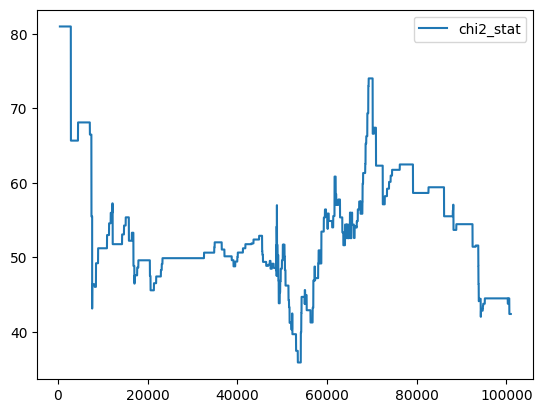

In [19]:
df_first_digits.select("chi2_stat").to_pandas().plot()

In [20]:
df_group = (
    df_group
    .with_columns_seq(
        df_first_digits.select("chi2_stat")
    )
)

<h4>Output created features</h4>

In [21]:
df_features = (
    df_group.lazy()
    .rolling(index_column="time", period="1d")
    .agg(
        rolling_whale_imbalance_ratio = pl.col("whale_imbalance_ratio").mean(),
        rolling_regular_imbalance_ratio= pl.col("regular_imbalance_ratio").mean(),

        *[pl.col(col).mean().alias(f"{col}_mean") for col in weekday_cols],
        *[pl.col(col).max().alias(f"{col}_max") for col in weekday_cols],

        *[pl.col(col).mean().alias(f"{col}_mean") for col in hour_cols],
        *[pl.col(col).max().alias(f"{col}_max") for col in hour_cols],

        *[
            pl.col("chi2_stat").mean().alias("chi2_stat_mean"),
            pl.col("chi2_stat").max().alias("chi2_stat_max"),
        ],
    )
).collect()

In [22]:
df_features = (
    df_features
    .filter(
        (pl.col("time") <= pump.pump_time) & 
        (pl.col("time") >= pump.pump_time - timedelta(hours=24*14))
    )
    .to_pandas()
)

In [23]:
df_features = df_features.resample(
    on="time", rule="1h", offset=timedelta(
        minutes=pump.pump_time.minute,
        seconds=pump.pump_time.second,
    )
).first()

In [24]:
df_features = df_features.reset_index(drop=True)

In [25]:
df_features.index = [f"{i}_H" for i in range(1, 24 * 14+1)]
df_features = df_features.unstack().to_frame().sort_index(level=1).T
df_features.columns = df_features.columns.map("_".join)

In [26]:
df_features

,chi2_stat_max_100_H,chi2_stat_mean_100_H,hour_0-3_max_100_H,hour_0-3_mean_100_H,hour_12-15_max_100_H,hour_12-15_mean_100_H,hour_15-18_max_100_H,hour_15-18_mean_100_H,hour_18-21_max_100_H,hour_18-21_mean_100_H,...,weekday_3_max_9_H,weekday_3_mean_9_H,weekday_4_max_9_H,weekday_4_mean_9_H,weekday_5_max_9_H,weekday_5_mean_9_H,weekday_6_max_9_H,weekday_6_mean_9_H,weekday_7_max_9_H,weekday_7_mean_9_H
0,55.876824,55.21002,0.0,0.0,0.316387,0.287643,0.126766,0.11525,2.228324e-17,9.686622e-15,...,0.180546,0.147213,0.117088,0.095471,0.253144,0.206408,0.091182,0.074348,0.339368,0.300041
